<a href="https://colab.research.google.com/github/nuraini2502/MachineLearning/blob/Praktikum9/PraktikumMandiri.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praktikum Mandiri



Nama : Nuraini

NIM : 0110222170

Matkul : Machine Learning | Sesi Pagi

Loading Data

In [1]:
# Memanggil library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score # membagi dataset menjadi data pelatihan dan data pengujian
from sklearn.preprocessing import StandardScaler # Digunakan untuk melakukan Standardisasi fitur numerik , mengubah data agar memiliki rata-rata 0 dan standar deviasi 1.
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report # Metrik evaluasi yang digunakan untuk menilai performa model
from sklearn.naive_bayes import GaussianNB #Model klasifikasi yang akan digunakan, yaitu Gaussian Naive Bayes.

In [2]:
# Mengambil data pada google drive
from google.colab import drive
drive.mount('/content/gdrive')
df = pd.read_csv('/content/gdrive/MyDrive/MachineLearning/Praktikum/data/week9/data.csv')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [3]:
# Menampilkan 5 baris pertama pada data
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
df.info() # untuk mendapatkan ringkasan ringkas dari suatu DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

Missing Value

In [5]:
df.isnull().sum() # menghitung total nilai yang hilang (missing values)

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [6]:
# Menghapus kolom yang tidak relevan untuk pemodelan
df = df.drop(['id', 'Unnamed: 32'], axis=1) # menghapus kolom-kolom yang tidak relevan dari DataFrame

In [7]:
# Cek missing value
df.isnull().sum()

,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0


Encoding Kategorikal

In [8]:
# Encoding Variabel Target
df['diagnosis'] = df['diagnosis'].replace({'M': 1, 'B': 0})

/tmp/ipython-input-2981364226.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['diagnosis'] = df['diagnosis'].replace({'M': 1, 'B': 0})


Separating, Splitting, dan Scaling Data

In [9]:
# memisahkan data menjadi dua komponen utama
X = df.drop('diagnosis', axis=1)
Y = df['diagnosis']

In [10]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)
# membagi seluruh data Anda menjadi empat set data yang terpisah.

print(X.shape,X_train.shape, X_test.shape)

(569, 30) (455, 30) (114, 30)


In [11]:
# Standardisasi Data untuk Naive Baye
scaler = StandardScaler() # Membuat instance (objek) dari kelas
X_train_scaled = scaler.fit_transform(X_train) # Menganalisis dan mentransformasi data pelatihan
X_test_scaled = scaler.transform(X_test) # Pengujian menggunakan statistik dari data pelatihan

In [12]:
# Inisialisasi dan Pelatihan
nb_model = GaussianNB() # model yang akan Anda gunakan untuk klasifikasi
nb_model.fit(X_train_scaled, Y_train) # melatih model menggunakan '(X_train_scaled, Y_train)'

GaussianNB()

Accuracy Score & Evaluation

In [13]:
#Accuracy
train_pred_nb = nb_model.predict(X_train_scaled) # untuk membuat prediksi pada data pelatihan
test_pred_nb = nb_model.predict(X_test_scaled) # untuk membuat prediksi pada data pengujian

print('Training Accuracy:', accuracy_score(Y_train, train_pred_nb)) # Menghitung Akurasi Pelatihan
print('Testing Accuracy:', accuracy_score(Y_test, test_pred_nb)) # Menghitung Akurasi Pengujian

Training Accuracy: 0.945054945054945
Testing Accuracy: 0.9210526315789473


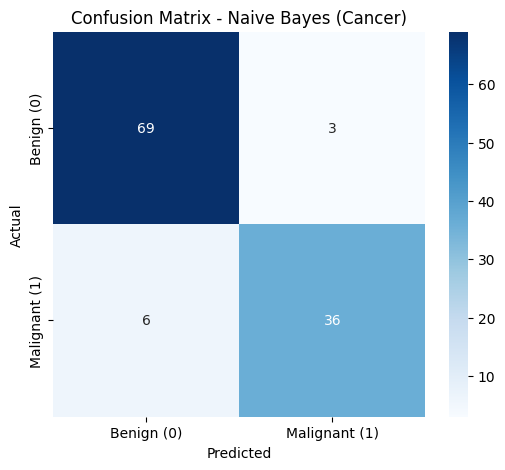

In [15]:
# Visualisasi Confusion Matrix
cm_nb = confusion_matrix(Y_test, test_pred_nb) # Moved from a later cell to define cm_nb
plt.figure(figsize=(6, 5)) # Menyiapkan Kanvas dengan ukuran berikut
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign (0)', 'Malignant (1)'], yticklabels=['Benign (0)', 'Malignant (1)']) # membuat heatmap
# Menambahkan label
plt.title('Confusion Matrix - Naive Bayes (Cancer)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show() # Menampilkan plot

In [16]:
# Classification Report
print("\nClassification Report (Testing Data):") # Menghasilkan laporan evaluasi
print(classification_report(Y_test, test_pred_nb, target_names=['Benign (0)', 'Malignant (1)']))
# test_pred_nb = prediksi yang dihasilkan oleh model Naive Bayes pada data pengujian
# target_names=['Benign (0)', 'Malignant (1)'] = Memberikan nama yang mudah dibaca (Benign/Malignant) pada label numerik (0 dan 1)


Classification Report (Testing Data):
               precision    recall  f1-score   support

   Benign (0)       0.92      0.96      0.94        72
Malignant (1)       0.92      0.86      0.89        42

     accuracy                           0.92       114
    macro avg       0.92      0.91      0.91       114
 weighted avg       0.92      0.92      0.92       114



Cross Valisadi

In [17]:
# Confusion Matrix
cm_nb = confusion_matrix(Y_test, test_pred_nb) # menghitung matriks
print("Confusion Matrix (Testing Data):\n", cm_nb) # menampilkan ringkasan testing data

Confusion Matrix (Testing Data):
 [[69  3]
 [ 6 36]]


In [18]:
cv_scores = cross_val_score(nb_model, X_train_scaled, Y_train, cv=5, scoring='accuracy')

print("\nNaive Bayes Cross Validation Accuracy (5-fold):")
print(f"CV Scores: {cv_scores}") # menampilkan 5 nilai akurasi individual
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}") # menhitung rata-rata
print(f"Std Deviation CV: {cv_scores.std():.4f}") # menghitung standar deviasi


Naive Bayes Cross Validation Accuracy (5-fold):
CV Scores: [0.92307692 0.98901099 0.92307692 0.92307692 0.93406593]
Mean CV Accuracy: 0.9385
Std Deviation CV: 0.0256
